In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def f1(t, y):
    return (1 + 4*t) - y

def exact1(t):
    return 4*t - 3 + 4*np.exp(-t)

In [3]:
def euler_method(f, t0, y0, h, tend):
    n = int(round((tend - t0) / h))
    t = np.zeros(n+1)
    y = np.zeros(n+1)
    t[0] = t0
    y[0] = y0
    for i in range(n):
        y[i+1] = y[i] + h * f(t[i], y[i])
        t[i+1] = t[i] + h
    return t, y

In [4]:
def heun_method(f, t0, y0, h, tend):
    n = int(round((tend - t0) / h))
    t = np.zeros(n+1)
    y = np.zeros(n+1)
    t[0] = t0
    y[0] = y0
    for i in range(n):
        k1 = f(t[i], y[i])
        y_pred = y[i] + h * k1
        k2 = f(t[i] + h, y_pred)
        y[i+1] = y[i] + (h / 2.0) * (k1 + k2)
        t[i+1] = t[i] + h
    return t, y

In [5]:
h_list1 = [0.50, 0.25, 0.1, 0.01, 0.001]
t0, y0, tend = 0, 1, 5

euler_results1 = {}
heun_results1 = {}

for h in h_list1:
    te, ye = euler_method(f1, t0, y0, h, tend)
    th, yh = heun_method(f1, t0, y0, h, tend)
    
    yexact_e = exact1(te)
    yexact_h = exact1(th)
    
    err_e = np.abs(yexact_e - ye)
    err_h = np.abs(yexact_h - yh)
    
    euler_results1[h] = (te, ye, yexact_e, err_e)
    heun_results1[h] = (th, yh, yexact_h, err_h)

In [6]:
for h in h_list1:
    te, ye, yexact_e, err_e = euler_results1[h]
    print(f"\n--- Euler Method Table (h = {h}) ---")
    print(f"{'t':>6}{'Euler y':>15}{'Exact y':>15}{'Error':>15}")
    for i in range(len(te)):
        print(f"{te[i]:6.3f}{ye[i]:15.6f}{yexact_e[i]:15.6f}{err_e[i]:15.6f}")

for h in h_list1:
    th, yh, yexact_h, err_h = heun_results1[h]
    print(f"\n--- Heun Method Table (h = {h}) ---")
    print(f"{'t':>6}{'Heun y':>15}{'Exact y':>15}{'Error':>15}")
    for i in range(len(th)):
        print(f"{th[i]:6.3f}{yh[i]:15.6f}{yexact_h[i]:15.6f}{err_h[i]:15.6f}")


--- Euler Method Table (h = 0.5) ---
     t        Euler y        Exact y          Error
 0.000       1.000000       1.000000       0.000000
 0.500       1.000000       1.426123       0.426123
 1.000       2.000000       2.471518       0.471518
 1.500       3.500000       3.892521       0.392521
 2.000       5.250000       5.541341       0.291341
 2.500       7.125000       7.328340       0.203340
 3.000       9.062500       9.199148       0.136648
 3.500      11.031250      11.120790       0.089540
 4.000      13.015625      13.073263       0.057638
 4.500      15.007812      15.044436       0.036623
 5.000      17.003906      17.026952       0.023046

--- Euler Method Table (h = 0.25) ---
     t        Euler y        Exact y          Error
 0.000       1.000000       1.000000       0.000000
 0.250       1.000000       1.115203       0.115203
 0.500       1.250000       1.426123       0.176123
 0.750       1.687500       1.889466       0.201966
 1.000       2.265625       2.471518   

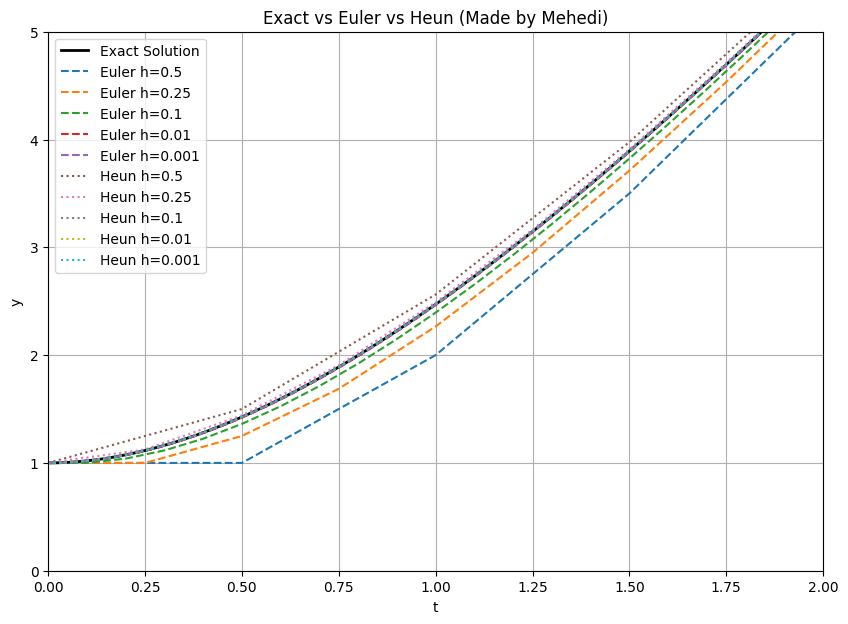

In [7]:
plt.figure(figsize=(10, 7))
tt = np.linspace(t0, tend, 500)
plt.plot(tt, exact1(tt), 'k-', linewidth=2, label='Exact Solution')

for h in h_list1:
    te, ye, _, _ = euler_results1[h]
    plt.plot(te, ye, '--', label=f'Euler h={h}')

for h in h_list1:
    th, yh, _, _ = heun_results1[h]
    plt.plot(th, yh, ':', label=f'Heun h={h}')

plt.xlabel('t')
plt.ylabel('y')
plt.title('Exact vs Euler vs Heun (Made by Mehedi)')
plt.xlim(0, 2)
plt.ylim(0, 5)
plt.legend()
plt.grid(True)
plt.show()